#### Load libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  confusion_matrix
from sklearn.linear_model import Lasso
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from imblearn.metrics import geometric_mean_score
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, cross_validate
import os
os.makedirs('Images/outputs', exist_ok=True)

#### Load data

In [40]:
df_soil = pd.read_csv('../data/texas.csv')
df_weather = pd.read_csv('../data/texas_weather_2015_2025.csv')

In [41]:
# See how the data look like
display(df_soil.head())
display(df_weather.head())

,areasymbol,areaname,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,hzdept_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r
0,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0
1,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0
2,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0
3,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN
4,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN


,fips_code,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,prcp_10,prcp_11,prcp_12,tmax_1,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmax_10,tmax_11,tmax_12,tmin_1,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,48001,2.900933,2.964329,3.390561,5.274802,5.482412,3.368956,2.154338,2.213802,2.021631,2.804362,2.772327,3.546515,14.801700,17.294464,22.125136,24.969758,28.683150,32.577329,34.656327,35.097864,32.271312,27.488296,20.868623,17.419984,2.700309,5.342215,9.778649,12.752341,17.891575,21.907337,23.292819,23.144735,19.783293,13.743153,8.519413,5.796549
1,48003,0.618085,0.249359,0.634158,1.418229,1.921028,2.696040,1.638462,2.639070,2.541667,2.535465,1.346667,0.917178,13.554131,16.993851,22.128919,26.017898,30.871698,34.920571,35.771386,35.125876,31.040653,25.653221,19.683191,16.032286,-0.822571,0.930097,5.899730,9.574432,15.242857,19.786648,21.337168,20.795148,17.274184,11.027731,4.795467,1.361318
2,48005,5.320645,3.733105,4.570246,6.129650,7.832726,4.051328,3.969763,4.530125,3.920284,3.818794,3.957512,5.619541,15.619215,18.365723,22.983311,25.744783,29.333848,32.990290,34.669915,34.851966,32.254783,27.816690,21.708175,18.211577,3.263854,5.918182,10.375305,13.729855,18.534270,22.242754,23.302825,23.010253,20.027536,14.020337,9.096930,6.289610
3,48007,2.281019,0.937309,2.306885,2.215823,4.492989,4.979784,2.275115,2.194407,4.977037,2.320145,2.293601,1.146378,18.735501,21.021630,24.568545,27.090094,30.091667,32.604527,33.263472,34.012121,32.631894,29.347715,24.266046,21.384893,7.368022,10.111556,15.333683,18.327041,22.442424,25.037123,25.531995,25.269433,23.523677,18.877358,14.045899,10.673762
4,48009,1.350183,1.603846,2.189388,2.864894,4.556282,3.304078,1.509524,2.039051,3.147477,2.820037,1.864552,1.038868,13.777419,18.357143,22.800000,25.843333,29.497143,32.624561,36.831148,35.177419,32.020000,28.654839,22.686667,12.803226,-0.948387,3.578571,7.225806,11.340000,15.262857,20.372414,22.993443,21.267742,17.873333,12.383871,7.016667,-0.370968


#### Merge data

In [42]:
# Tweak fips code so that they can be merged
df_soil['fips_code'] = df_soil['areasymbol'].str.replace("TX", "")
df_weather['fips_code'] = df_weather['fips_code'].astype(str).replace(r'^\d{2}', "", regex=True)

# See the change
print(df_soil['fips_code'].head())
print(df_weather['fips_code'].head())

0    129
1    129
2    129
3    129
4    129
Name: fips_code, dtype: str
0    001
1    003
2    005
3    007
4    009
Name: fips_code, dtype: str


In [43]:
# Count how many different unique code in the data
print(df_soil['fips_code'].nunique())
print(df_weather['fips_code'].nunique())

# What are in weather not soil
in_weather_not_soil = set(df_weather['fips_code'].unique()) - set(df_soil['fips_code'].unique())
print(f"In weather but not soil: {len(in_weather_not_soil)}")
print(sorted(in_weather_not_soil))

# What are in soil not weather
in_soil_not_weather = set(df_soil['fips_code'].unique()) - set(df_weather['fips_code'].unique())
print(f"In soil but not weather: {len(in_soil_not_weather)}")
print(sorted(in_soil_not_weather))

232
252
In weather but not soil: 49
['007', '015', '031', '043', '049', '053', '063', '067', '091', '103', '109', '119', '127', '135', '137', '141', '159', '183', '209', '221', '223', '229', '241', '245', '257', '261', '273', '277', '315', '333', '343', '351', '361', '373', '379', '383', '385', '397', '403', '405', '407', '409', '425', '449', '459', '461', '473', '495', '507']
In soil but not weather: 29
['393', '600', '601', '602', '603', '604', '605', '606', '607', '608', '609', '610', '611', '612', '613', '614', '615', '616', '617', '618', '619', '620', '621', '622', '623', '624', '625', '626', '627']


In [44]:
not_in_weather = ['393', '600', '601', '602', '603', '604', '605', '606', '607', '608', '609', '610', '611', '612', '613', '614', '615', '616', '617', '618', '619', '620', '621', '622', '623', '624', '625', '626', '627']
place = df_soil[df_soil['fips_code'].isin(not_in_weather)][['areasymbol', 'areaname']]
print(place.groupby('areasymbol')['areaname'].unique())

areasymbol
TX393                              [Roberts County, Texas]
TX600                  [Austin and Waller Counties, Texas]
TX601                  [Blanco and Burnet Counties, Texas]
TX602                    [Brown and Mills Counties, Texas]
TX603    [Camp, Franklin, Morris, and Titus Counties, T...
TX604                     [Comal and Hays Counties, Texas]
TX605                  [Dimmit and Zavala Counties, Texas]
TX606                    [Ector and Crane Counties, Texas]
TX607                   [Edwards and Real Counties, Texas]
TX608                   [Upshur and Gregg Counties, Texas]
TX609                 [Hood and Somervell Counties, Texas]
TX610                  [Hopkins and Rains Counties, Texas]
TX611                  [Jasper and Newton Counties, Texas]
TX612               [Kaufman and Rockwall Counties, Texas]
TX613                 [Kenedy and Kleberg Counties, Texas]
TX614                    [Lamar and Delta Counties, Texas]
TX615                 [Loving and Winkler Cou

In [45]:
# Change fips_code in weather to meet the criteria of soil data
fips_to_areasymbol = {
    '015': '600', '473': '600',
    '031': '601', '053': '601',
    '049': '602', '333': '602',
    '063': '603', '159': '603', '343': '603', '449': '603',
    '091': '604', '209': '604',
    '127': '605', '507': '605',
    '135': '606', '103': '606',
    '137': '607', '385': '607',
    '459': '608', '183': '608',
    '221': '609', '425': '609',
    '223': '610', '379': '610',
    '241': '611', '351': '611',
    '257': '612', '397': '612',
    '261': '613', '273': '613',
    '277': '614', '119': '614',
    '301': '615', '495': '615',
    '315': '616', '067': '616',
    '373': '617', '407': '617',
    '383': '618', '461': '618',
    '405': '619', '403': '619',
    '409': '620', '007': '620',
    '043': '621',
    '245': '623', '361': '623',
    '141': '624',
    '109': '625',
    '229': '627',
}
df_weather['fips_code'] = df_weather['fips_code'].replace(fips_to_areasymbol)
in_weather_not_soil = set(df_weather['fips_code'].unique()) - set(df_soil['fips_code'].unique())

In [46]:
# See if applied
print(f"In weather but not soil: {len(in_weather_not_soil)}")
print(in_weather_not_soil)

In weather but not soil: 0
set()


In [47]:
# Merge 2 data
df = pd.merge(df_soil, df_weather, on='fips_code')

In [48]:
display(df.head())
display(df.columns)

,areasymbol,areaname,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,hzdept_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r,fips_code,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,prcp_10,prcp_11,prcp_12,tmax_1,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmax_10,tmax_11,tmax_12,tmin_1,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0,129,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
1,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0,129,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
2,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0,129,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
3,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN,129,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
4,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN,129,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639


Index(['areasymbol', 'areaname', 'musym', 'muname', 'compname', 'saverest',
       'taxorder', 'drainagecl', 'elev_r', 'slope_r', 'hzdept_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'nonirryield_r', 'irryield_r', 'fips_code', 'prcp_1',
       'prcp_2', 'prcp_3', 'prcp_4', 'prcp_5', 'prcp_6', 'prcp_7', 'prcp_8',
       'prcp_9', 'prcp_10', 'prcp_11', 'prcp_12', 'tmax_1', 'tmax_2', 'tmax_3',
       'tmax_4', 'tmax_5', 'tmax_6', 'tmax_7', 'tmax_8', 'tmax_9', 'tmax_10',
       'tmax_11', 'tmax_12', 'tmin_1', 'tmin_2', 'tmin_3', 'tmin_4', 'tmin_5',
       'tmin_6', 'tmin_7', 'tmin_8', 'tmin_9', 'tmin_10', 'tmin_11',
       'tmin_12'],
      dtype='str')

#### Features
* We drop areasymbol because the is identification of the area. That does not have meaning itself.
* We drop musym and muname because taxorder indicates the soil type more briefly than those. They are too specifi to use.
* We drop saverest because this is updated data and all are updated in Sepetember in 2025.
* We drop hzdept because all values in this column is 0.

| Column | Description | Usage |
| --- | --- | --- |
| areasymbol | A unique code that identifies a specific soil survey area | Drop |
| areaname | The name given to the specified geographic area | Drop |
| musym | A short unique identifier used to label a specific map unit within a single soil survey area | Drop |
| muname | The full, formal name of the soil unit | Drop |
| compname | Name of soil component, very specific than taxorder | Drop |
| saverest | Time stamp represent the exact date and time of soil data | Drop |
| taxorder | The highest level in Soil Taxonomy or Soil type| Feature |
| drainagecl | Drainage class | Feature |
| elev_r | Altitude or elevation | Feature |
| slope_r | Slope | Feature |
| hzdept_r | The distance from the top of the soil surface to the upper boundary of a specific soil horizon | Drop |
| hzdepb_r | The distance from the top of the soil surface to the lower boundary of a specific soil horizon | Feature |
| ph1to1h2o_r | pH | Feature |
| om_r | Nutrient | Feature |
| ec_r | EC (electrical Conductivity) | Feature |
| cec7_r | CEC (Cation Exchange Capacity) | Feature
| awc_r | AWC (Available Water Capacity) | Feature
| cropname | The name of crops | Target for crop recommendation |
| yldunits | Crop yield units per unit area for the specified crop | Use when standardizeing the crop yield |
| nonirryield_r | The expected yield per acre of the specific crop without irrigation | Target for crop yield prediction |
| irryield_r | The expected yield per acre of the specific crop with irrigation | Target for crop yield prediction |
| fips_code | The identification number of county | Drop |
| prcp_ | The pricipation of specific month (mm) | Feature |
| tmax_ | The average maximum temperature of specific month (C) | Feature |
| tmin_ | The average minimum temperature of specfici month (C) | Feature |


https://docs.google.com/document/d/1hZgvWIYF03py2quTsW1hpOCYE-pO2eVkZ7HLiCrpQ7E/edit?tab=t.0

### Yield prediction

In [49]:
df = df.drop([
    'areasymbol', 
    'areaname',
    'musym', 
    'muname',
    'compname', 
    'saverest',
    'hzdept_r', 
    'fips_code'], 
    axis=1)

In [50]:
display(df.head())
display(df.columns)

,taxorder,drainagecl,elev_r,slope_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,prcp_10,prcp_11,prcp_12,tmax_1,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmax_10,tmax_11,tmax_12,tmin_1,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
1,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
2,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
3,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
4,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639


Index(['taxorder', 'drainagecl', 'elev_r', 'slope_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'nonirryield_r', 'irryield_r', 'prcp_1', 'prcp_2', 'prcp_3',
       'prcp_4', 'prcp_5', 'prcp_6', 'prcp_7', 'prcp_8', 'prcp_9', 'prcp_10',
       'prcp_11', 'prcp_12', 'tmax_1', 'tmax_2', 'tmax_3', 'tmax_4', 'tmax_5',
       'tmax_6', 'tmax_7', 'tmax_8', 'tmax_9', 'tmax_10', 'tmax_11', 'tmax_12',
       'tmin_1', 'tmin_2', 'tmin_3', 'tmin_4', 'tmin_5', 'tmin_6', 'tmin_7',
       'tmin_8', 'tmin_9', 'tmin_10', 'tmin_11', 'tmin_12'],
      dtype='str')

In [51]:
# Drop duplicates
df = df.drop_duplicates()
pd.set_option('display.max_columns', None)
df.head()

,taxorder,drainagecl,elev_r,slope_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,prcp_10,prcp_11,prcp_12,tmax_1,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmax_10,tmax_11,tmax_12,tmin_1,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
1,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
2,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
3,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
4,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN,0.53629,0.255752,0.730968,2.294,4.612903,1.866667,2.156774,3.140645,1.57,0.977419,2.288333,0.379032,10.151613,16.268235,20.624731,22.981111,25.739785,31.91,35.044444,33.298387,31.185,26.248276,19.048333,12.577419,-4.056522,-2.470588,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639


In [52]:
print(df.shape)
print(df.info())
print(df.describe())

(52553, 50)
<class 'pandas.DataFrame'>
Index: 52553 entries, 0 to 54202
Data columns (total 50 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   taxorder       51763 non-null  str    
 1   drainagecl     52041 non-null  str    
 2   elev_r         52528 non-null  float64
 3   slope_r        52553 non-null  float64
 4   hzdepb_r       52553 non-null  int64  
 5   ph1to1h2o_r    51952 non-null  float64
 6   om_r           51889 non-null  float64
 7   ec_r           51955 non-null  float64
 8   cec7_r         47105 non-null  float64
 9   awc_r          51957 non-null  float64
 10  cropname       48558 non-null  str    
 11  yldunits       48553 non-null  str    
 12  nonirryield_r  44260 non-null  float64
 13  irryield_r     12816 non-null  float64
 14  prcp_1         52553 non-null  float64
 15  prcp_2         52385 non-null  float64
 16  prcp_3         52553 non-null  float64
 17  prcp_4         52385 non-null  float64
 18  prcp_5    

#### Unit conversion

<StringArray>
['Tons', 'Lbs', 'Bu', 'AUM', 'Sacks', 'Boxes', nan, 'Crates']
Length: 8, dtype: str


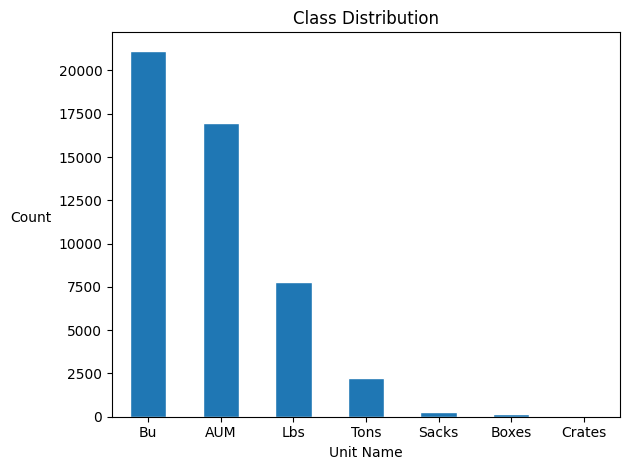

In [53]:
print(df['yldunits'].unique())

df['yldunits'].value_counts().plot(
    kind='bar',
    edgecolor='white', 
    width=0.5
)

plt.xticks(rotation=0)
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Unit Name')
plt.ylabel('Count', rotation=0, labelpad=20)
plt.tight_layout()
plt.show()

* Weight (Tons, Lbs)
* Volume (Bu, Sacks, Boxes, Crates)
* Carrying capacity (AUM)

Since units measure different things, we cannot standardize all of them across the category. For example we cannot convert Boxes to Lbs because a "Box" of oranges doesn't weigh the same as a "Box" of strawberries. 

https://www.grainunitconverter.com/
In USDA, a sack is almost equivalent to CWT
We arbitrarily set the conversion rate.
Standardize Lbs
| Crop | Unit | Lb |
| --- | --- | --- |
| Anything | 1 US ton | 2000 lbs |
| Grain sorghum | 1 Bu | 56 lbs |
| Corn | 1 Bu | 56 lbs |
| Wheat/Winter wheat | 1 Bu | 60 lbs |
| Oats | 1 Bu | 34 lbs |
| Peaches | 1 Bu | 48 lbs?|
| Soybeans | 1 Bu | 60 lbs |
| Green peas | 1 Bu | 60 lbs |
| Flax | 1 Bu | 56 lbs |
| Rye | 1 Bu | 56 lbs |
| Rice | 1 Bu | 45 lbs? |
| Barley | 1 Bu | 48 lbs |
| Carrots | 1 Bu | 50 lbs? |
| Onions | 1 sack | 100 lbs? |
| Grapefruit | 1 box | 85 lbs? |
| Oranges | 1 box | 90 lbs? |
| Cantaloupe | 1 crate | 80 lbs? |
| Cabbage | 1 crate | 50 lbs? |
| Anything | 1 AUM | 800 lbs? |


In [54]:
weight = df[df['yldunits'].isin(['Tons', 'Lbs'])]['cropname'].unique()
volume = df[df['yldunits'].isin(['Bu', 'Sacks', 'Boxes', 'Crates'])]['cropname'].unique()
capacity = df[df['yldunits'] == 'AUM']['cropname'].unique()

display(weight)
display(volume)
display(capacity)

# df = df.drop('yldunits', axis=1)

<StringArray>
[     'Alfalfa hay',      'Cotton lint',    'Grain sorghum',
      'Watermelons',        'Sugarcane',          'Peanuts',
      'Sorghum hay',      'Corn silage',           'Alfafa',
         'Dry peas',   'Sorghum silage',          'Spinach',
       'Sunflowers', 'Small grains hay',        'Grass hay',
       'Legume hay', 'Pima cotton lint']
Length: 17, dtype: str

<StringArray>
['Grain sorghum',         'Wheat',          'Corn',  'Winter wheat',
        'Onions',    'Grapefruit',       'Oranges',          'Oats',
       'Peaches',      'Soybeans',          'Rice',          'Flax',
        'Barley',    'Green peas',       'Carrots',           'Rye',
    'Cantaloupe',       'Cabbage']
Length: 18, dtype: str

<StringArray>
['Improved bermudagrass',     'Weeping lovegrass',          'Buffel grass',
            'Kleingrass',            'Bahiagrass',   'Common bermudagrass',
    'Caucasian bluestem',   'Introduced bluestem', 'Small grains grazeout',
           'Tall fescue',        'Sorghum grazed',            'Cantaloupe',
        'Wheat grazeout',       'Tall wheatgrass',               'Pasture']
Length: 15, dtype: str

In [55]:
# Mapping: (cropname, yldunits) -> lbs_per_unit
# None as cropname means "any crop" for that unit
YIELD_CONVERSION = {
    ("Grain sorghum",     "Bu"):    56,
    ("Corn",              "Bu"):    56,
    ("Wheat",             "Bu"):    60,
    ("Winter wheat",      "Bu"):    60,
    ("Oats",              "Bu"):    34,
    ("Peaches",           "Bu"):    48,
    ("Soybeans",          "Bu"):    60,
    ("Green peas",        "Bu"):    60,
    ("Flax",              "Bu"):    56,
    ("Rye",               "Bu"):    56,
    ("Rice",              "Bu"):    45,
    ("Barley",            "Bu"):    48,
    ("Carrots",           "Bu"):    50,
    ("Onions",            "Sack"): 100,
    ("Grapefruit",        "Box"):   85,
    ("Oranges",           "Box"):   90,
    ("Cantaloupe",        "Crate"): 80,
    ("Cabbage",           "Crate"): 50,
    (None,                "Tons"): 2000,
    (None,                "AUM"):   800,
    (None,                "Lbs"):     1,
}

def get_lbs_per_unit(cropname: str, yldunits: str) -> float | None:
    """Look up lbs per unit, trying (crop, unit) first, then (None, unit)."""
    return YIELD_CONVERSION.get((cropname, yldunits)) \
        or YIELD_CONVERSION.get((None, yldunits))

# Vectorized: build a multiplier column, then apply once
df["lbs_per_unit"] = df.apply(
    lambda row: get_lbs_per_unit(row["cropname"], row["yldunits"]),
    axis=1
)

# Warn about any unrecognized crop/unit combos before overwriting data
missing = df[df["lbs_per_unit"].isna()][["cropname", "yldunits"]].drop_duplicates()
if not missing.empty:
    print("WARNING: no conversion found for:\n", missing.to_string(index=False))

df["nonirryield_r_lb"] = df["nonirryield_r"] * df["lbs_per_unit"]
df["irryield_r_lb"]    = df["irryield_r"]    * df["lbs_per_unit"]

df.drop(columns="lbs_per_unit", inplace=True)

   cropname yldunits
    Onions    Sacks
Grapefruit    Boxes
   Oranges    Boxes
  Soybeans      NaN
       NaN      NaN
  Pumpkins      NaN
Cantaloupe   Crates
   Cabbage   Crates


In [56]:
df[["cropname", "yldunits", "nonirryield_r", "nonirryield_r_lb", "irryield_r", "irryield_r_lb"]]

,cropname,yldunits,nonirryield_r,nonirryield_r_lb,irryield_r,irryield_r_lb
0,Alfalfa hay,Tons,3.0,6000.0,6.0,12000.0
1,Cotton lint,Lbs,225.0,225.0,600.0,600.0
2,Grain sorghum,Bu,25.0,1400.0,75.0,4200.0
3,Grain sorghum,Bu,50.0,2800.0,NaN,NaN
4,Improved bermudagrass,AUM,6.0,4800.0,NaN,NaN
...,...,...,...,...,...,...
54196,NaN,NaN,NaN,NaN,NaN,NaN
54197,NaN,NaN,NaN,NaN,NaN,NaN
54198,NaN,NaN,NaN,NaN,NaN,NaN
54199,NaN,NaN,NaN,NaN,NaN,NaN


#### Missing values

In [57]:
print(df.isnull().sum())

# Count missing valus if both are null
print((df["nonirryield_r_lb"].isna() & df["irryield_r_lb"].isna()).sum())

taxorder              790
drainagecl            512
elev_r                 25
slope_r                 0
hzdepb_r                0
ph1to1h2o_r           601
om_r                  664
ec_r                  598
cec7_r               5448
awc_r                 596
cropname             3995
yldunits             4000
nonirryield_r        8293
irryield_r          39737
prcp_1                  0
prcp_2                168
prcp_3                  0
prcp_4                168
prcp_5                168
prcp_6                168
prcp_7                168
prcp_8                168
prcp_9                168
prcp_10               168
prcp_11               168
prcp_12               168
tmax_1               4347
tmax_2               4347
tmax_3               4347
tmax_4               4347
tmax_5               4347
tmax_6               4347
tmax_7               4347
tmax_8               4347
tmax_9               4347
tmax_10              4347
tmax_11              4347
tmax_12              4347
tmin_1      

In [58]:
# If one has value and the other has null, then let null be 0
df.loc[df['nonirryield_r_lb'].notna() & df['irryield_r_lb'].isna(), 'irryield_r_lb'] = 0
df.loc[df['irryield_r_lb'].notna() & df['nonirryield_r_lb'].isna(), 'nonirryield_r_lb'] = 0

df['yield'] = df['nonirryield_r_lb'] + df['irryield_r_lb']

In [59]:
# See the change
print(df[['nonirryield_r_lb', 'irryield_r_lb', 'yield']])

       nonirryield_r_lb  irryield_r_lb    yield
0                6000.0        12000.0  18000.0
1                 225.0          600.0    825.0
2                1400.0         4200.0   5600.0
3                2800.0            0.0   2800.0
4                4800.0            0.0   4800.0
...                 ...            ...      ...
54196               NaN            NaN      NaN
54197               NaN            NaN      NaN
54198               NaN            NaN      NaN
54199               NaN            NaN      NaN
54202               NaN            NaN      NaN

[52553 rows x 3 columns]


In [60]:
# Drop rows whose columns are null
df = df.dropna(subset=['nonirryield_r_lb', 'irryield_r_lb', 'yield'], how="all")

# Drop them
df = df.drop(['cropname', 'nonirryield_r', 'irryield_r', 'nonirryield_r_lb', 'irryield_r_lb', 'yldunits'], axis=1)

In [61]:
# Check the update
print(df[['yield']])
print(df.isnull().sum())

         yield
0      18000.0
1        825.0
2       5600.0
3       2800.0
4       4800.0
...        ...
49987   3360.0
49988    350.0
49989   3080.0
49990   4800.0
49991   1800.0

[47828 rows x 1 columns]
taxorder          3
drainagecl        0
elev_r            0
slope_r           0
hzdepb_r          0
ph1to1h2o_r      13
om_r             13
ec_r             10
cec7_r         4560
awc_r            13
prcp_1            0
prcp_2          141
prcp_3            0
prcp_4          141
prcp_5          141
prcp_6          141
prcp_7          141
prcp_8          141
prcp_9          141
prcp_10         141
prcp_11         141
prcp_12         141
tmax_1         4068
tmax_2         4068
tmax_3         4068
tmax_4         4068
tmax_5         4068
tmax_6         4068
tmax_7         4068
tmax_8         4068
tmax_9         4068
tmax_10        4068
tmax_11        4068
tmax_12        4068
tmin_1         4068
tmin_2         4068
tmin_3         4068
tmin_4         4068
tmin_5         4068
tmin_6        

#### Split the data

In [62]:
X = df.drop('yield', axis=1)
y = df['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [63]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['str', 'object']).columns

print(num_cols)
print(cat_cols)

Index(['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r',
       'cec7_r', 'awc_r', 'prcp_1', 'prcp_2', 'prcp_3', 'prcp_4', 'prcp_5',
       'prcp_6', 'prcp_7', 'prcp_8', 'prcp_9', 'prcp_10', 'prcp_11', 'prcp_12',
       'tmax_1', 'tmax_2', 'tmax_3', 'tmax_4', 'tmax_5', 'tmax_6', 'tmax_7',
       'tmax_8', 'tmax_9', 'tmax_10', 'tmax_11', 'tmax_12', 'tmin_1', 'tmin_2',
       'tmin_3', 'tmin_4', 'tmin_5', 'tmin_6', 'tmin_7', 'tmin_8', 'tmin_9',
       'tmin_10', 'tmin_11', 'tmin_12'],
      dtype='str')
Index(['taxorder', 'drainagecl'], dtype='str')


#### Polynomial linear regression

In [64]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())

])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
                    drop='first',
                    handle_unknown='ignore',
                    sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2)),
    ('lasso', Lasso(alpha=0.01))
])

In [65]:
# lasso_pipeline.fit(X_train, y_train)
# y_train_pred = lasso_pipeline.predict(X_train)
# y_test_pred = lasso_pipeline.predict(X_test)

# print(mean_squared_error(y_train, y_train_pred))
# print(mean_squared_error(y_test, y_test_pred))

In [66]:
# coeffs = lasso_pipeline.named_steps['lasso'].coef_
# living_features = np.sum(coeffs != 0)
# print(f"Important features: {living_features} / {len(coeffs)}")

In [67]:
# cv_results = cross_validate(
#     lasso_pipeline, X, y,
#     cv=5,
#     scoring={
#         'neg_mse': 'neg_mean_squared_error',
#         'r2':      'r2'
#     }
# )

# fold_scores = cv_results['test_neg_mse']
# mean_score  = fold_scores.mean()
# std_score   = fold_scores.std()

# print(f"Neg-MSE per fold: {fold_scores.round(4)}")
# print(f"Mean:             {mean_score:.4f} (+/- {std_score:.4f})")
# print(f"R²:               {cv_results['test_r2'].mean():.4f}")

In [68]:
# rmse_scores = np.sqrt(-cv_results['test_neg_mse'])
# mean_rmse   = rmse_scores.mean()
# std_rmse    = rmse_scores.std()

# fig, ax = plt.subplots(figsize=(8, 4))

# # Lower RMSE is better, so highlight bars below the mean in blue
# colors = ['#4C8BF5' if s <= mean_rmse else '#F5A623' for s in rmse_scores]
# folds  = [f"Fold {i+1}" for i in range(len(rmse_scores))]

# bars = ax.bar(folds, rmse_scores, color=colors, edgecolor='white', linewidth=0.8, zorder=3)

# ax.axhline(mean_rmse, color='#E24B4A', linestyle='--', linewidth=1.5,
#            label=f'Mean RMSE: {mean_rmse:.4f}', zorder=4)
# ax.fill_between(range(len(rmse_scores)),
#                 mean_rmse - std_rmse,
#                 mean_rmse + std_rmse,
#                 alpha=0.12, color='#E24B4A', zorder=2,
#                 label=f'±1 std: {std_rmse:.4f}')

# for bar, score in zip(bars, rmse_scores):
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
#             f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ax.set_ylabel('RMSE')
# ax.set_title('K-Fold Cross-Validation Results (RMSE)', fontsize=12, fontweight='bold')
# ax.set_ylim(max(0, rmse_scores.min() - 0.05), rmse_scores.max() + 0.06)  # no upper cap of 1
# ax.set_xticks(range(len(folds)))
# ax.set_xticklabels(folds)
# ax.legend(fontsize=9)
# ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
# ax.set_facecolor('#F9F9F9')

#### XGBoost

In [69]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBRegressor(random_state=42))
])

In [70]:
# xgb_pipeline.fit(X_train, y_train)
# y_train_pred = xgb_pipeline.predict(X_train)
# y_test_pred = xgb_pipeline.predict(X_test)

# print(mean_squared_error(y_train, y_train_pred))
# print(mean_squared_error(y_test, y_test_pred))

In [71]:
cv_results = cross_validate(
    xgb_pipeline, X, y,
    cv=5,
    scoring={
        'neg_mse': 'neg_mean_squared_error',
        'r2':      'r2'
    }
)

fold_scores = cv_results['test_neg_mse']
mean_score  = fold_scores.mean()
std_score   = fold_scores.std()

print(f"Neg-MSE per fold: {fold_scores.round(4)}")
print(f"Mean:             {mean_score:.4f} (+/- {std_score:.4f})")
print(f"R²:               {cv_results['test_r2'].mean():.4f}")

Neg-MSE per fold: [-53780572.3621 -26699424.1984 -58876367.2601 -77936995.106
 -48550617.0472]
Mean:             -53168795.1948 (+/- 16543092.5003)
R²:               0.1938


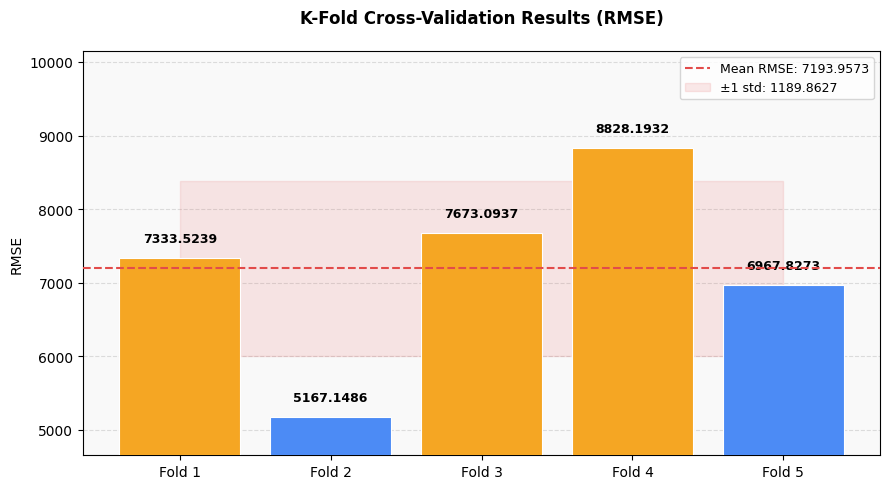

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rmse_scores = np.sqrt(-cv_results['test_neg_mse'])
mean_rmse   = rmse_scores.mean()
std_rmse    = rmse_scores.std()

fig, ax = plt.subplots(figsize=(9, 5))


colors = ['#4C8BF5' if s <= mean_rmse else '#F5A623' for s in rmse_scores]
folds  = [f"Fold {i+1}" for i in range(len(rmse_scores))]

bars = ax.bar(folds, rmse_scores, color=colors, edgecolor='white', linewidth=0.8, zorder=3)


ax.axhline(mean_rmse, color='#E24B4A', linestyle='--', linewidth=1.5,
           label=f'Mean RMSE: {mean_rmse:.4f}', zorder=4)


ax.fill_between(range(len(rmse_scores)),
                mean_rmse - std_rmse,
                mean_rmse + std_rmse,
                alpha=0.12, color='#E24B4A', zorder=2,
                label=f'±1 std: {std_rmse:.4f}')

offset = rmse_scores.max() * 0.02

for bar, score in zip(bars, rmse_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, 
            bar.get_height() + offset,
            f'{score:.4f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('RMSE')
ax.set_title('K-Fold Cross-Validation Results (RMSE)', fontsize=12, fontweight='bold', pad=20)


y_min = max(0, rmse_scores.min() * 0.9)
y_max = rmse_scores.max() * 1.15 
ax.set_ylim(y_min, y_max)

ax.set_xticks(range(len(folds)))
ax.set_xticklabels(folds)
ax.legend(loc='upper right', fontsize=9) 
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
ax.set_facecolor('#F9F9F9')


plt.tight_layout() 
plt.savefig('Images/outputs/yield_cv_rmse.png', dpi=150)
plt.show()

#### Neural network

In [73]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F


In [74]:
class YieldRegressor(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.all_layers = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 1)
        )

    def forward(self, x):
        return self.all_layers(x)
    

class MyDataset(Dataset):
    def __init__(self, X, y):       
        # Convert feature matrix to float32 tensor
        self.features = torch.tensor(X, dtype=torch.float32)
        # Convert label vector to int64 tensor
        self.labels = torch.tensor(y, dtype=torch.float32)

    def __getitem__(self, index):
        # Returns one (feature, label) pair at a given index
        x = self.features[index]
        y = self.labels[index]
        return x, y

    def __len__(self):
        # Returns the total number of samples
        return self.labels.shape[0]
    
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, path="best_model.pt"):
        self.patience  = patience  
        self.min_delta = min_delta  
        self.path      = path       
        self.best_loss = float("inf")
        self.counter   = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path) 
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [75]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

y_train_log = np.log1p(y_train)  # log(1 + y)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

train_ds = MyDataset(X_train_processed, y_train_log)
val_ds   = MyDataset(X_val_processed,   y_val_log)
test_ds  = MyDataset(X_test_processed,  y_test_log)

train_loader = DataLoader(dataset=train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(dataset=val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(dataset=test_ds,  batch_size=32, shuffle=False)

In [76]:
torch.manual_seed(1)
model = YieldRegressor(num_features=X_train_processed.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
early_stopping = EarlyStopping(patience=10, min_delta=1e-4)

num_epochs = 20
train_losses = []
val_losses   = []

for epoch in range(num_epochs):
    model = model.train()
    batch_losses = []

    for batch_idx, (features, targets) in enumerate(train_loader):
        targets = targets.view(-1, 1).float()

        outputs = model(features)
        loss = F.mse_loss(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(train_loss)

    model = model.eval()
    batch_val_losses = []
    with torch.inference_mode():
        for features, targets in val_loader:
            targets = targets.view(-1, 1).float()
            val_outputs = model(features)
            val_loss = F.mse_loss(val_outputs, targets)
            batch_val_losses.append(val_loss.item())

    val_loss = sum(batch_val_losses) / len(batch_val_losses)
    val_losses.append(val_loss)

    print(f"Epoch: {epoch+1:03d}/{num_epochs:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Patience: {early_stopping.counter}/{early_stopping.patience}")

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load("best_model.pt"))
print(f"Best Val Loss: {early_stopping.best_loss:.4f}")

Epoch: 001/020 | Train Loss: 1.5813 | Val Loss: 0.9079 | Patience: 0/10
Epoch: 002/020 | Train Loss: 1.1742 | Val Loss: 0.8557 | Patience: 0/10
Epoch: 003/020 | Train Loss: 1.1481 | Val Loss: 1.0114 | Patience: 0/10
Epoch: 004/020 | Train Loss: 1.1102 | Val Loss: 1.0279 | Patience: 1/10
Epoch: 005/020 | Train Loss: 1.0906 | Val Loss: 0.8615 | Patience: 2/10
Epoch: 006/020 | Train Loss: 1.0729 | Val Loss: 0.9441 | Patience: 3/10
Epoch: 007/020 | Train Loss: 1.0640 | Val Loss: 0.8397 | Patience: 4/10
Epoch: 008/020 | Train Loss: 1.0475 | Val Loss: 0.8552 | Patience: 0/10
Epoch: 009/020 | Train Loss: 1.0363 | Val Loss: 0.9085 | Patience: 1/10
Epoch: 010/020 | Train Loss: 1.0269 | Val Loss: 1.1931 | Patience: 2/10
Epoch: 011/020 | Train Loss: 1.0075 | Val Loss: 1.1008 | Patience: 3/10
Epoch: 012/020 | Train Loss: 0.9981 | Val Loss: 0.8034 | Patience: 4/10
Epoch: 013/020 | Train Loss: 0.9872 | Val Loss: 0.8547 | Patience: 0/10
Epoch: 014/020 | Train Loss: 0.9887 | Val Loss: 0.8261 | Patienc

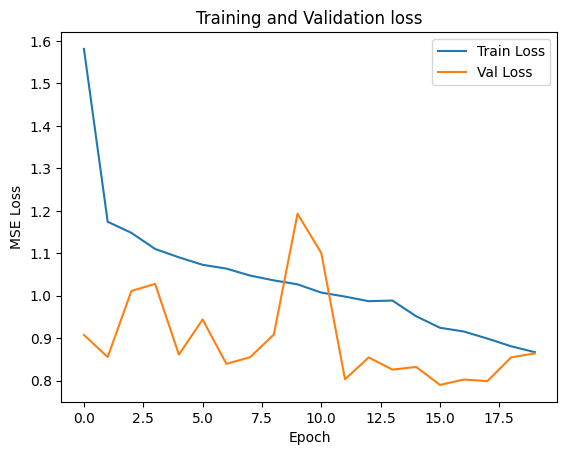

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation loss")
plt.legend()
plt.savefig('Images/outputs/yield_train_val_loss.png', dpi=150)
plt.show()

In [78]:
model.eval()
preds, actuals = [], []

with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        pred = model(X_batch).squeeze()
        preds.extend(pred.numpy())
        actuals.extend(y_batch.numpy())

preds_original   = np.expm1(preds)
actuals_original = np.expm1(actuals)

from sklearn.metrics import root_mean_squared_error, r2_score
print(f"Test RMSE: {root_mean_squared_error(actuals_original, preds_original):.4f}")
print(f"Test R²:   {r2_score(actuals_original, preds_original):.4f}")

Test RMSE: 5045.6167
Test R²:   0.0398
